In [42]:
from google.colab import drive
import zipfile
import os

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
zip_path = '/content/drive/MyDrive/Plant_Disease_Classification_224.zip'

In [45]:
extract_path = '/content/Plant_Disease_Classification_224'

In [46]:
import os
os.makedirs(extract_path, exist_ok=True)

In [47]:
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")
print("Files are available at:", extract_path)

Dataset unzipped successfully!
Files are available at: /content/Plant_Disease_Classification_224


In [48]:
os.listdir(extract_path)

['test.csv',
 'train',
 'train.csv',
 'valid',
 'label.num_disease.json',
 'test',
 'valid.csv']

In [49]:
import os
import json
import pandas as pd

In [50]:
DATASET_PATH = "/content/Plant_Disease_Classification_224"

In [51]:
train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [52]:
train_csv_path = os.path.join(DATASET_PATH, "train.csv")
valid_csv_path = os.path.join(DATASET_PATH, "valid.csv")
test_csv_path  = os.path.join(DATASET_PATH, "test.csv")

In [53]:
label_json_path = os.path.join(DATASET_PATH, "label_num_disease.json")

In [54]:
train_df = pd.read_csv(train_csv_path)
valid_df = pd.read_csv(valid_csv_path)
test_df = pd.read_csv(test_csv_path)

In [55]:
label_json_path = os.path.join(DATASET_PATH, "label.num_disease.json")

with open(label_json_path, "r") as f:
    label_map = json.load(f)

print("Dataset loaded successfully!")
print("Train images folder:", train_dir)
print("Valid images folder:", valid_dir)
print("Test images folder:", test_dir)

print("\nTrain CSV shape:", train_df.shape)
print("Valid CSV shape:", valid_df.shape)
print("Test CSV shape:", test_df.shape)

print("\nTrain CSV columns:")
print(train_df.columns)

print("\nLabel mapping:")
print(label_map)

Dataset loaded successfully!
Train images folder: /content/Plant_Disease_Classification_224/train
Valid images folder: /content/Plant_Disease_Classification_224/valid
Test images folder: /content/Plant_Disease_Classification_224/test

Train CSV shape: (5000, 3)
Valid CSV shape: (1448, 3)
Test CSV shape: (1930, 3)

Train CSV columns:
Index(['image_path', 'label', 'disease_name'], dtype='object')

Label mapping:
{'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


In [56]:
train_df.head()

,image_path,label,disease_name
0,train/Cassava___bacterial_blight/2932123995_jp...,0,Cassava___bacterial_blight
1,train/Cassava___bacterial_blight/1410898675_jp...,0,Cassava___bacterial_blight
2,train/Cassava___bacterial_blight/416062259_jpg...,0,Cassava___bacterial_blight
3,train/Cassava___bacterial_blight/2998282647_jp...,0,Cassava___bacterial_blight
4,train/Cassava___bacterial_blight/3504991692_jp...,0,Cassava___bacterial_blight


In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [58]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5000 images belonging to 5 classes.
Found 1448 images belonging to 5 classes.
Found 1930 images belonging to 5 classes.


In [59]:
print("Number of classes:", train_generator.num_classes)
print("Class names:", train_generator.class_indices)

Number of classes: 5
Class names: {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


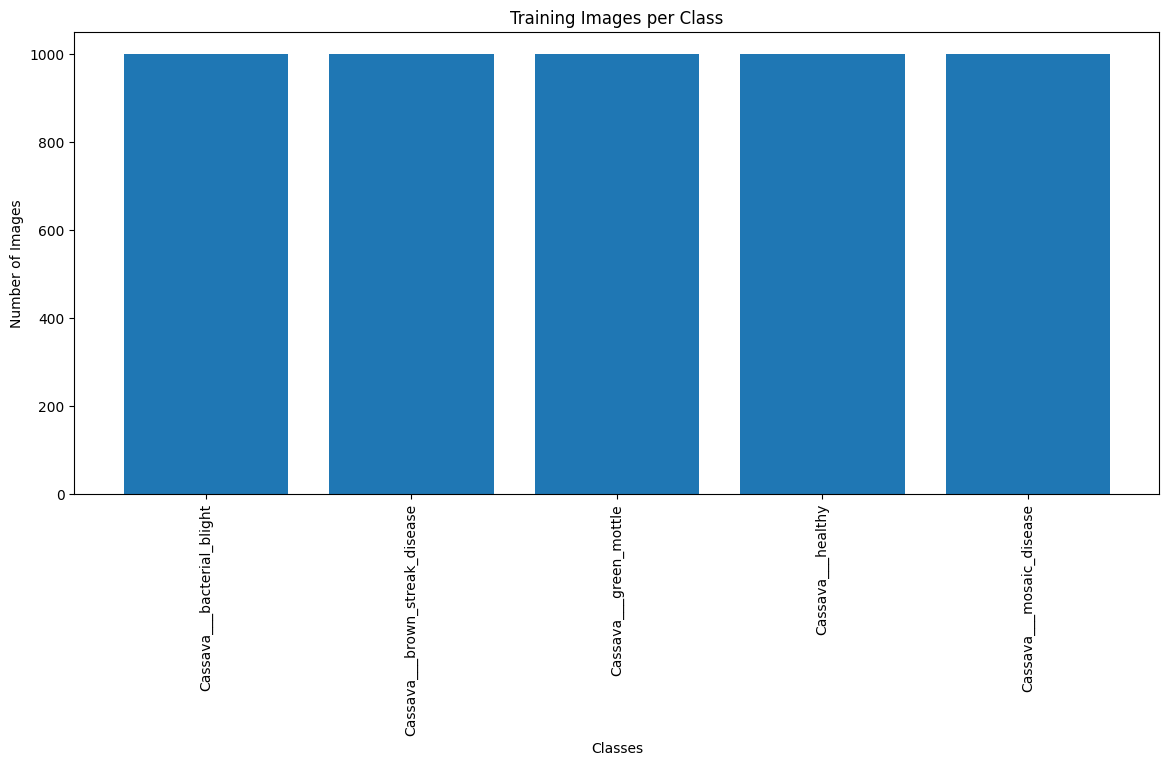

In [60]:
import matplotlib.pyplot as plt
import os

class_names = list(train_generator.class_indices.keys())
class_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts.append(count)

plt.figure(figsize=(14, 6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Training Images per Class")
plt.show()

In [61]:
for name, count in zip(class_names, class_counts):
    print(name, ":", count)

Cassava___bacterial_blight : 1000
Cassava___brown_streak_disease : 1000
Cassava___green_mottle : 1000
Cassava___healthy : 1000
Cassava___mosaic_disease : 1000


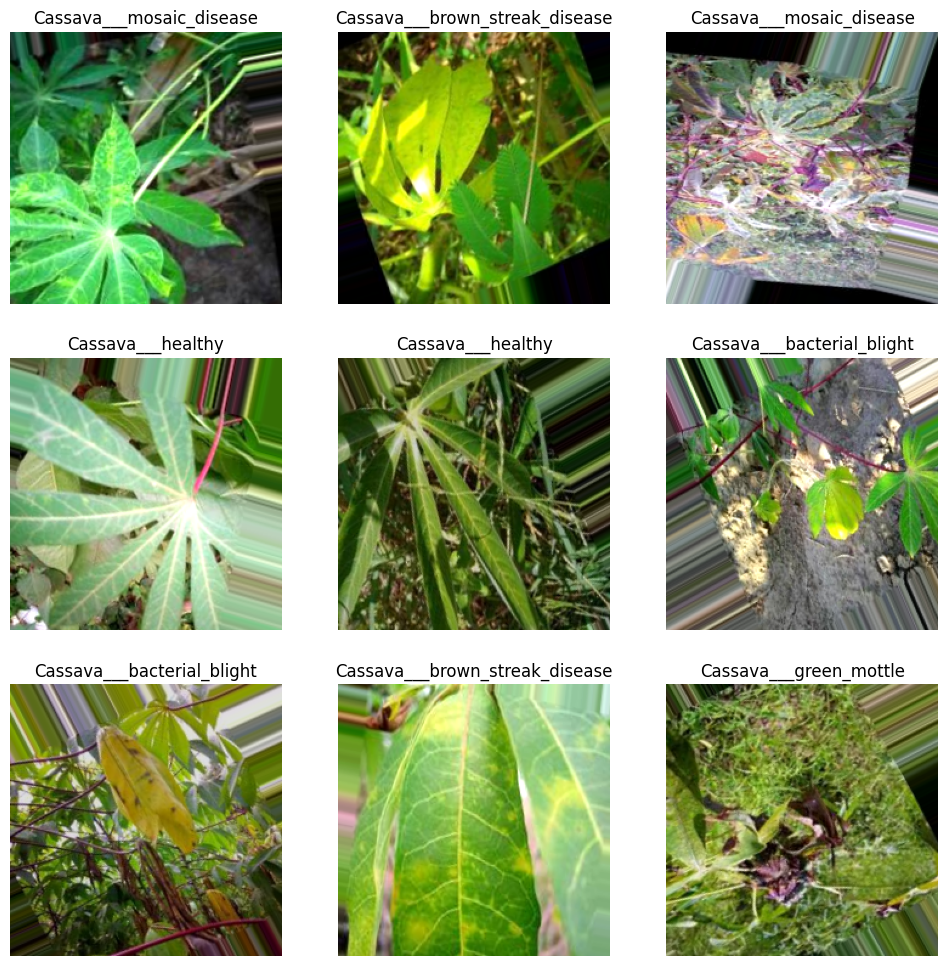

In [62]:
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = class_names[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [63]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D

In [64]:
IMG_SIZE = 224
NUM_CLASSES = train_generator.num_classes

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model first
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.5),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dropout(0.4),

    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [65]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [66]:
callbacks = [
    ModelCheckpoint(
        "best_regularized_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [67]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.2076 - loss: 2.4643
Epoch 1: val_accuracy improved from None to 0.35635, saving model to best_regularized_model.keras

Epoch 1: finished saving model to best_regularized_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 99s 559ms/step - accuracy: 0.2436 - loss: 2.3215 - val_accuracy: 0.3564 - val_loss: 2.0792 - learning_rate: 1.0000e-04
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.3041 - loss: 2.1282
Epoch 2: val_accuracy improved from 0.35635 to 0.38812, saving model to best_regularized_model.keras

Epoch 2: finished saving model to best_regularized_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 460ms/step - accuracy: 0.3138 - loss: 2.1106 - val_accuracy: 0.3881 - val_loss: 1.9979 - learning_rate: 1.0000e-04
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.3419 - loss: 2.0539
Epoch 3: val_accuracy improved from 0.38812 to 0.41160, saving model to best_regularized_model.keras

Epoch 3: fi

In [68]:
base_model.trainable = True

# Freeze first layers, train only last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

In [69]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [70]:
fine_callbacks = [
    ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=fine_callbacks
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.3538 - loss: 1.8920
Epoch 1: val_accuracy improved from None to 0.51381, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 115s 597ms/step - accuracy: 0.3994 - loss: 1.7467 - val_accuracy: 0.5138 - val_loss: 1.5054 - learning_rate: 1.0000e-05
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.4533 - loss: 1.6203
Epoch 2: val_accuracy did not improve from 0.51381
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 484ms/step - accuracy: 0.4700 - loss: 1.5951 - val_accuracy: 0.4855 - val_loss: 1.6352 - learning_rate: 1.0000e-05
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.4856 - loss: 1.5512
Epoch 3: val_accuracy did not improve from 0.51381

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 470ms/step - accuracy: 0.5026 - loss: 1.5315 - val_accuracy: 0.4841 

In [71]:
from tensorflow.keras.models import load_model

best_model = load_model("best_finetuned_model.keras")

test_loss, test_accuracy = best_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.5285 - loss: 1.4301
Test Loss: 1.430082082748413
Test Accuracy: 0.5284973978996277


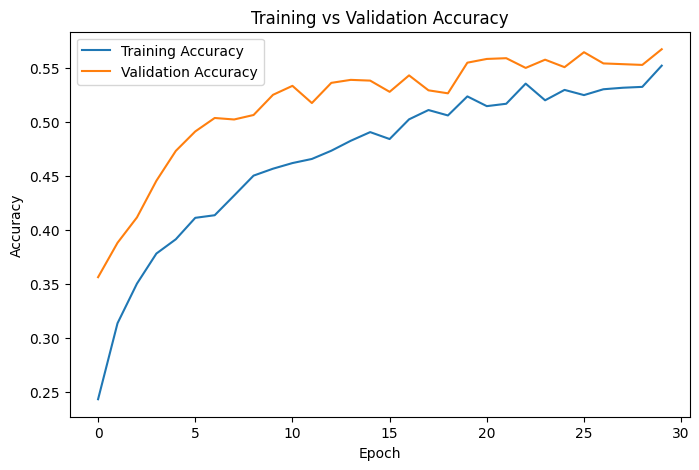

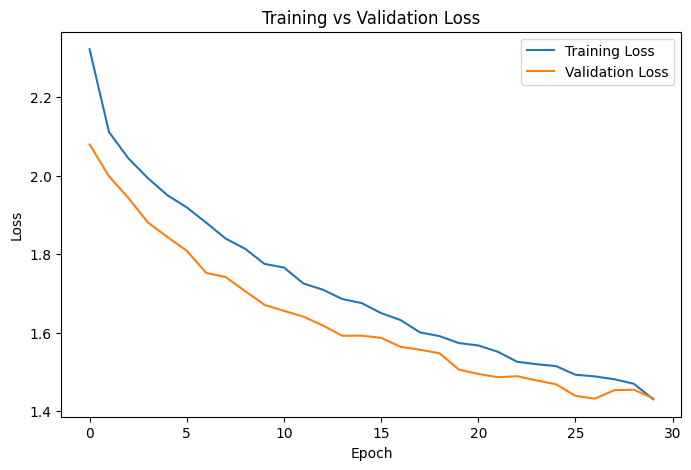

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()